Use random forest regression to predict the amount of building
materials released from a demolition site.

## Imports

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

## Data

In [5]:
real_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")
# Switch to select either real or generated data
data = real_data

X = data[["Area", "Volume", "Storeys"]].values
concrete = data[["Concrete"]].values
mineral_wool = data[["Mineral_wool"]].values
metal = data[["Metal"]].values
glass = data[["Glass"]].values


# Fit & test

[-0.24480757  0.01590064 -0.15289051  0.20788202 -0.80584752  0.62482108]
[4, 3, 1]


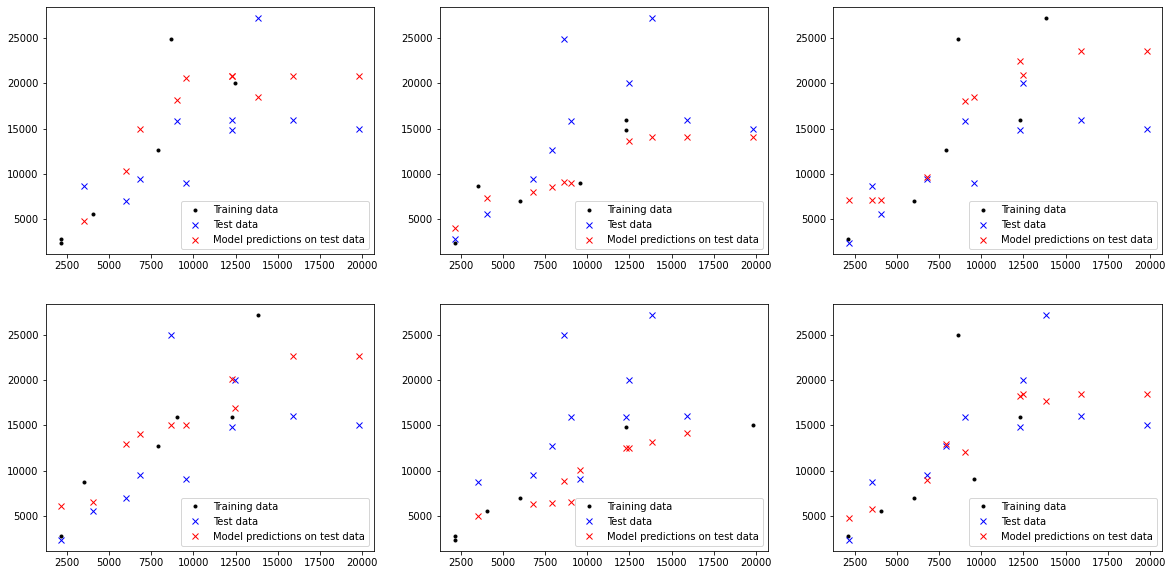

In [6]:
# Replace the argument with {concrete, mineral_wool, glass, metal}
# to select material to predict.
y = np.ravel(concrete)
max_depths = range(2,6)
min_samples = range(2,5)
min_leaf_samples = range(1,4)
best_score = -np.inf

for max_depth in max_depths:
   for min_samples_split in min_samples:
      for min_samples_leaf in min_leaf_samples:
         scores = np.zeros(6)
         regr = RandomForestRegressor(
             max_depth=max_depth,
             min_samples_split=min_samples_split,
             min_samples_leaf=min_samples_leaf,
             max_features=2
         )

         for i in range(6):

            X_tr, X_tst, y_tr, y_tst = train_test_split(
               X, y, test_size=0.6)

            # X_tr = real_data[["Area", "Storeys", "Concrete"]].iloc[:, :-1].values
            # y_tr = real_data[["Area", "Storeys", "Concrete"]].iloc[:, -1].values
            # X_tst = generated_data[["Area", "Storeys", "Concrete"]].iloc[:, :-1].values
            # y_tst = generated_data[["Area", "Storeys", "Concrete"]].iloc[:, -1].values

            regr.fit(X_tr, y_tr)
            y_pred = regr.predict(X_tst)
            score = regr.score(X_tst, y_tst)
            scores[i] = score
         
         mean_score = np.mean(scores)
         if mean_score > best_score:
            best_score = mean_score
            best_max_depth = max_depth
            best_min_samples_split = min_samples_split
            best_min_samples_leaf = min_samples_leaf

scores = np.zeros(6)
fig = plt.figure(figsize=[20.0,10.0])
regr = RandomForestRegressor(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=2
)

for i in range(6):

   X_tr, X_tst, y_tr, y_tst = train_test_split(X, y, test_size=0.6)
   regr.fit(X_tr, y_tr)

   # X_tr = real_data[["Area", "Storeys", "Concrete"]].iloc[:, :-1].values
   # y_tr = real_data[["Area", "Storeys", "Concrete"]].iloc[:, -1].values
   # X_tst = generated_data[["Area", "Storeys", "Concrete"]].iloc[:, :-1].values
   # y_tst = generated_data[["Area", "Storeys", "Concrete"]].iloc[:, -1].values

   y_pred = regr.predict(X_tst)
   scores[i] = regr.score(X_tst, y_tst)

   plt.subplot(230 + i + 1)
   plt.plot(X_tr[:, 0], y_tr, '.k', label='Training data')
   plt.plot(X_tst[:, 0], y_tst, 'bx', label='Test data')
   plt.plot(X_tst[:, 0], y_pred, 'rx',
                  label='Model predictions on test data')
   plt.legend()
   
print(scores)
print([best_max_depth, best_min_samples_split, best_min_samples_leaf])
plt.show()
